In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
dataset_path = "/content/drive/MyDrive/face_analysis/Datasets"

In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1803 files belonging to 6 classes.
Using 1443 files for training.
Found 1803 files belonging to 6 classes.
Using 360 files for validation.


In [ ]:
class_names = train_ds.class_names

print(class_names)

['acne', 'blackheads', 'clear skin', 'dark spots', 'puffy eyes', 'wrinkles']


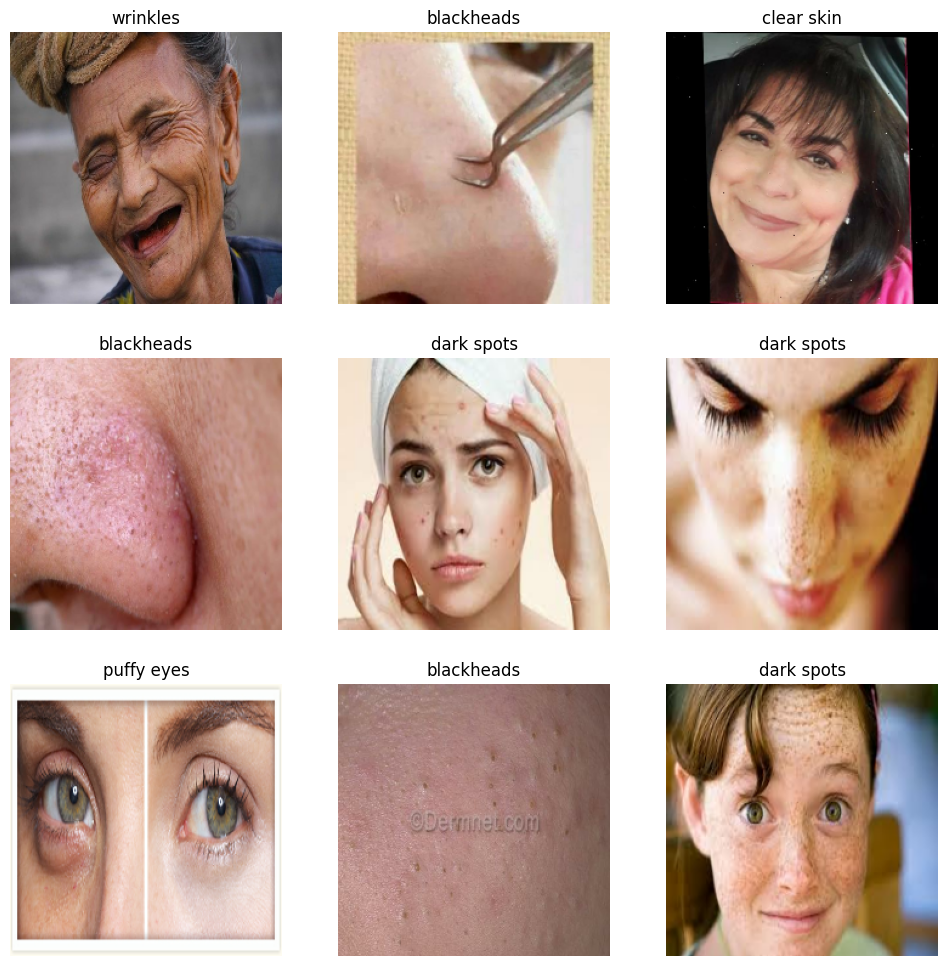

In [ ]:
# Display Sample Images

plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
# Optimize Dataset Performance

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [ ]:
# Load Pre-trained MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model
base_model.trainable = False

# Build the complete model
model = Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation="softmax")
])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compile the Model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Early Stopping Callback This prevents overfitting by stopping training if the validation accuracy stops improving

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
# Train the Model

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.8482 - loss: 0.4541 - val_accuracy: 0.8083 - val_loss: 0.5458
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8565 - loss: 0.4286 - val_accuracy: 0.7917 - val_loss: 0.5392
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.8704 - loss: 0.3859 - val_accuracy: 0.8083 - val_loss: 0.5345
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8801 - loss: 0.3469 - val_accuracy: 0.8139 - val_loss: 0.5110
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8843 - loss: 0.3273 - val_accuracy: 0.8111 - val_loss: 0.5049
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8988 - loss: 0.3121 - val_accuracy: 0.8194 - val_loss: 0.4786
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9023 - loss: 0.2890 - val_accuracy: 0.8361 - val_loss: 0.4606
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.9085 - loss: 0.2764 - val_accuracy: 0.8250 - val_loss:

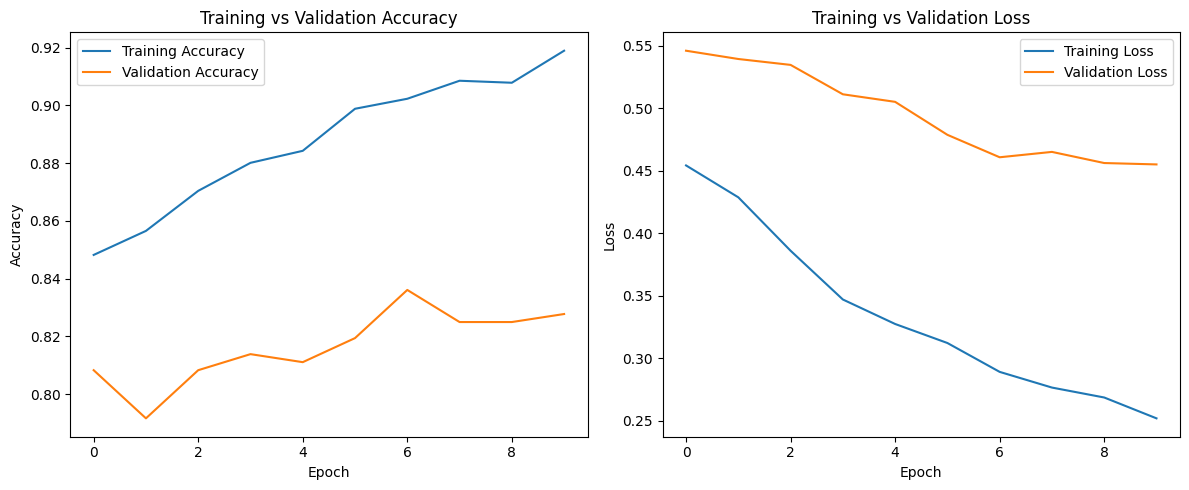

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("Evaluating model...")

loss, accuracy = model.evaluate(validation_dataset)

print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Evaluating model...
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 857ms/step - accuracy: 0.8278 - loss: 0.4549

Validation Loss: 0.4549
Validation Accuracy: 0.8278


In [ ]:
# Save the trained model

model.save("/content/drive/MyDrive/face_analysis/facial_skin_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
 from google.colab import files

uploaded = files.upload()

Saving clear_skin_007.jpg to clear_skin_007.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


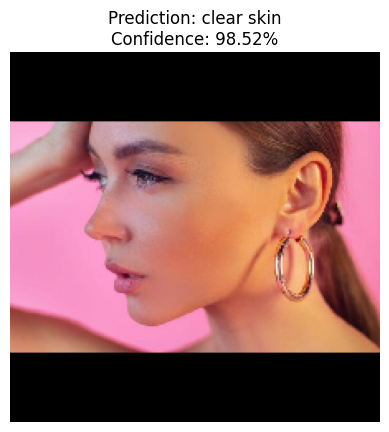

Predicted Skin Condition: clear skin
Confidence: 98.52%


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)


prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print(f"Predicted Skin Condition: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
# Generate predictions on validation dataset

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
print("Classification Report\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

Classification Report

              precision    recall  f1-score   support

        acne       0.76      0.82      0.79        57
  blackheads       0.80      0.80      0.80        49
  clear skin       0.98      0.92      0.95        63
  dark spots       0.80      0.79      0.80        57
  puffy eyes       0.81      0.82      0.81        67
    wrinkles       0.82      0.81      0.81        67

    accuracy                           0.83       360
   macro avg       0.83      0.83      0.83       360
weighted avg       0.83      0.83      0.83       360



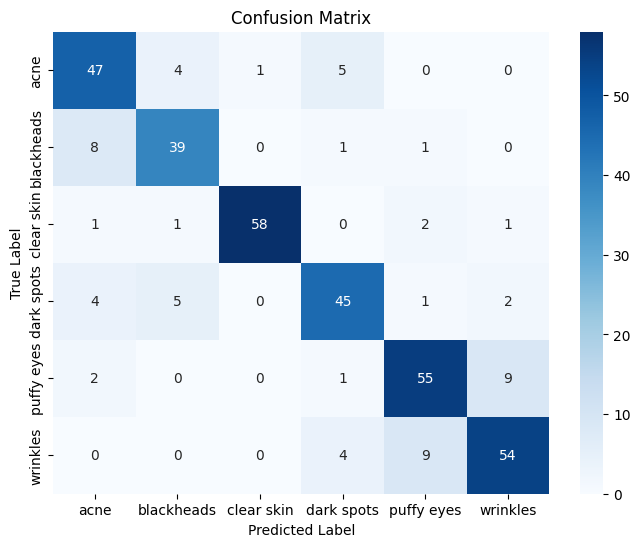

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [40]:
from google.colab import files

print("📤 Upload BEFORE image")
before_uploaded = files.upload()

print("\n📤 Upload AFTER image")
after_uploaded = files.upload()

before_path = list(before_uploaded.keys())[0]
after_path = list(after_uploaded.keys())[0]

📤 Upload BEFORE image


Saving 4.jpg to 4.jpg

📤 Upload AFTER image


Saving clear_skin_017.jpg to clear_skin_017.jpg


In [41]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_index = np.argmax(prediction)

    predicted_class = class_names[predicted_index]

    confidence = prediction[0][predicted_index] * 100

    return predicted_class, confidence, prediction[0]

In [47]:
before_class, before_confidence, before_scores = predict_image(before_path)

after_class, after_confidence, after_scores = predict_image(after_path)

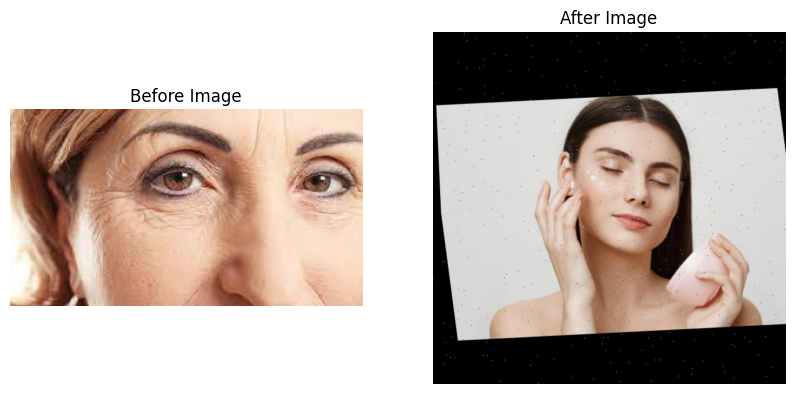

In [43]:
import matplotlib.pyplot as plt

before_img = image.load_img(before_path)
after_img = image.load_img(after_path)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(before_img)
plt.title("Before Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(after_img)
plt.title("After Image")
plt.axis("off")

plt.show()

In [44]:
print("="*60)
print("BEFORE IMAGE - PROBABILITY OF ALL CLASSES")
print("="*60)

for cls, prob in zip(class_names, before_scores):
    print(f"{cls:<15} : {prob*100:.2f}%")

print("\nPredicted Class :", before_class)

BEFORE IMAGE - PROBABILITY OF ALL CLASSES
acne            : 0.00%
blackheads      : 0.02%
clear skin      : 0.00%
darkspots       : 0.11%
puffy eyes      : 13.54%
wrinkles        : 86.33%

Predicted Class : wrinkles


In [45]:
print("="*60)
print("AFTER IMAGE - PROBABILITY OF ALL CLASSES")
print("="*60)

for cls, prob in zip(class_names, after_scores):
    print(f"{cls:<15} : {prob*100:.2f}%")

print("\nPredicted Class :", after_class)

AFTER IMAGE - PROBABILITY OF ALL CLASSES
acne            : 0.00%
blackheads      : 0.00%
clear skin      : 100.00%
darkspots       : 0.00%
puffy eyes      : 0.00%
wrinkles        : 0.00%

Predicted Class : clear skin


In [46]:
import pandas as pd

comparison_data = []

for cls, before_prob, after_prob in zip(class_names, before_scores, after_scores):

    before_percent = before_prob * 100
    after_percent = after_prob * 100

    difference = after_percent - before_percent

    if difference > 0:
        change = f"↑ {difference:.2f}%"
    elif difference < 0:
        change = f"↓ {abs(difference):.2f}%"
    else:
        change = "No Change"

    comparison_data.append([
        cls,
        f"{before_percent:.2f}%",
        f"{after_percent:.2f}%",
        change
    ])

comparison_df = pd.DataFrame(
    comparison_data,
    columns=["Skin Condition", "Before", "After", "Change"]
)

print("="*70)
print("BEFORE vs AFTER COMPARISON")
print("="*70)

display(comparison_df)

BEFORE vs AFTER COMPARISON


,Skin Condition,Before,After,Change
0,acne,0.00%,0.00%,↓ 0.00%
1,blackheads,0.02%,0.00%,↓ 0.02%
2,clear skin,0.00%,100.00%,↑ 100.00%
3,darkspots,0.11%,0.00%,↓ 0.11%
4,puffy eyes,13.54%,0.00%,↓ 13.54%
5,wrinkles,86.33%,0.00%,↓ 86.33%


In [39]:
print("="*70)
print("MODEL INTERPRETATION")
print("="*70)

print(f"Before Image Prediction : {before_class} ({before_confidence:.2f}%)")
print(f"After Image Prediction  : {after_class} ({after_confidence:.2f}%)")
print()

if before_class != after_class:
    print(f"✓ The model detected a change from '{before_class}' to '{after_class}'.")
else:
    print(f"✓ The model predicted the same condition ('{before_class}') in both images.")

print()

highest_before = before_scores.max()*100
highest_after = after_scores.max()*100

print(f"Highest confidence (Before): {highest_before:.2f}%")
print(f"Highest confidence (After) : {highest_after:.2f}%")

MODEL INTERPRETATION
Before Image Prediction : puffy eyes (94.83%)
After Image Prediction  : clear skin (82.29%)

✓ The model detected a change from 'puffy eyes' to 'clear skin'.

Highest confidence (Before): 94.83%
Highest confidence (After) : 82.29%
